# Feature Selection Visualization

### Archived old codes

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [10]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/tuberculosis/")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [11]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_sgimc.gz"}

In [12]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

In [5]:
from sgimc.utils import mc_split

In [6]:
from sgimc.utils import get_submatrix

In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }


def combine_with_identity(X, return_sparse=True):
    """Concatenates X with the identity matrix on the right."""

    assert X.ndim == 2, "Input matrix should have ndim = 2"

    X_add = np.eye(X.shape[0])
    X_comb = np.concatenate((X.toarray(), X_add), axis=1)

    if return_sparse:
        X_comb = sparsify_with_mask(X_comb, X_comb != 0)

    return X_comb

In [8]:
random_state = np.random.RandomState(0x0BADCAFE)

In [25]:
from sgimc.utils import load, save

X, Y, R_full = load(filename_input)
# X = combine_with_identity(X)

In [11]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

R_test = get_submatrix(R_full, ind_test)

In [17]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": [0.2],
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {
        "C_lasso": [0.0],
        "C_group": [1e0],
        "C_ridge": [1e0],
        "rank": [13],
    }
)

In [18]:
from sgimc import SparseGroupIMCClassifier

In [19]:
grid_dataset[0]

{'train_size': 0.2, 'n_splits': 5}

In [20]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split


results = []
for par_dtst in tqdm([grid_dataset[0]]):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        # set up the model
        C_lasso, C_group, C_ridge = (
            par_mdl["C_lasso"],
            par_mdl["C_group"],
            par_mdl["C_ridge"],
        )
        imc = SparseGroupIMCClassifier(
            par_mdl["rank"],
            n_threads=8,
            random_state=42,
            C_lasso=C_lasso,
            C_group=C_group,
            C_ridge=C_ridge,
        )

        # fit on the whole development dataset
        R_train = get_submatrix(R_full, ind_train_all)
        imc.fit(X, Y, R_train)

        # get the score
        prob_full = imc.predict_proba(X, Y)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(R_test, prob_test)
        d1_test = sum(abs(imc.coef_W_).max(axis=1) > 0)
        d2_test = sum(abs(imc.coef_H_).max(axis=1) > 0)

100%|██████████| 1/1 [00:17<00:00, 17.84s/it]


{'tn': 5352, 'fn': 420, 'fp': 311, 'tp': 2951, 'auc': 0.9686968651029522} 1443 22


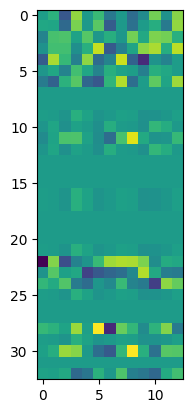

In [21]:
print(scores_test, d1_test, d2_test)
plt.imshow(imc.coef_H_)

---

#### Plot Figures

In [22]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/tuberculosis")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

In [23]:
idx_selected = np.where(np.max(np.abs(imc.coef_H_), axis=1) != 0)[0]
idx_selected

array([ 0,  1,  2,  3,  4,  5,  6,  9, 10, 11, 12, 16, 17, 21, 22, 23, 24,
       25, 28, 29, 30, 32])

In [24]:
SMARTS = {
    "Aromatic_ring": "a",  # any aromatic atom presence proxy
    "Heteroaromatic": "a[n,o,s]",  # aromatic atom that is hetero
    "Aliphatic_ring": "[R;!a]",  # non-aromatic ring atom exists
    "Primary_amine": "[NX3;H2]",  # -NH2
    "Secondary_amine": "[NX3;H1]",  # -NH-
    "Tertiary_amine": "[NX3;H0]",  # N with no H
    "Amide": "[CX3](=O)[NX3]",  # amide
    "Nitro": "[NX3](=O)=O",  # nitro
    "Nitrile": "C#N",  # nitrile
    "Carboxylic_acid": "C(=O)[OX2H1]",  # -COOH
    "Ester": "[CX3](=O)[OX2][#6]",  # ester approx
    "Alcohol": "[OX2H]",  # -OH
    "Phenol": "c[OX2H]",  # phenolic OH
    "Thiol": "[SX2H]",  # -SH
    "Thioether": "CS",  # C-S-C (heuristic)
    "Sulfoxide_sulfone": "[SX3](=O)",  # S=O
    "Any_halogen": "[F,Cl,Br,I]",  # any halogen atom
    "Fluorine": "F",
    "Chlorine": "Cl",
    "Bromine": "Br",
    "Iodine": "I",
    "Aromatic_halogen": "c[F,Cl,Br,I]",
    "Ether": "[OD2]([#6])[#6]",  # R-O-R
    "Imine": "C=N",
    "Lactam": "[$([NX3][CX3](=O)[R])]",  # heuristic
    "Lactone": "[OX2][CX3](=O)[R]",  # heuristic
    "Carboxamide_NH": "C(=O)N[H]",  # -CONH-
    "Sulfonamide": "S(=O)(=O)N",
    "Basic_center": "[NX3;!$(NC=O)]",  # amine not amide
    "Acidic_center": "C(=O)[OX2H1]",  # carboxyl-type acid
    "High_polar_N_O_count": "[#7,#8]",  # will count >=3 later
    "Aromatic_nitro": "[NX3](=O)=O",  # nitro on aromatic ring
    "Macrocycle": "R",  # ring presence (we refine below)
}

In [25]:
# Display-only representative structures (for figures/posters)
FG_DISPLAY = {
    "Aromatic_ring": "c1ccccc1",
    "Heteroaromatic": "c1ncccc1",
    "Aliphatic_ring": "C1CCCCC1",
    "Primary_amine": "CN",
    "Secondary_amine": "CNC",
    "Tertiary_amine": "CN(C)C",
    "Amide": "NC=O",
    "Nitro": "[N+](=O)[O-]",
    "Nitrile": "C#N",
    "Carboxylic_acid": "C(=O)O",
    "Ester": "CC(=O)OC",
    "Alcohol": "CO",
    "Phenol": "c1ccccc1O",
    "Thiol": "CS",
    "Thioether": "CSC",
    "Sulfoxide_sulfone": "CS(=O)C",
    "Any_halogen": "CF",
    "Fluorine": "CF",
    "Chlorine": "CCl",
    "Bromine": "CBr",
    "Iodine": "CI",
    "Aromatic_halogen": "c1ccccc1F",
    "Ether": "COC",
    "Imine": "C=N",
    "Lactam": "O=C1NCCC1",  # β-lactam–like ring (schematic)
    "Lactone": "O=C1OCCC1",  # lactone ring (schematic)
    "Carboxamide_NH": "C(=O)N",
    "Sulfonamide": "S(=O)(=O)NC",
    # 🔹 conceptual features → schematic icons
    "Basic_center": "CN=C",
    "Acidic_center": "C(=O)O",
    "High_polar_N_O_count": "NCCO",
    "Aromatic_nitro": "c1ccccc1[N+](=O)[O-]",
    "Macrocycle": "C1CCCCCCCC1",
}

In [26]:
feature_names = list(SMARTS.keys())
selected_features = [feature_names[i] for i in idx_selected]

#### Statistical figures

In [27]:
import pandas as pd

save_dir = (
    "/Users/sijianfan/Documents/projects/BiSSGL/datasets/realAnalysis/tuberculosis"
)
filename = "drugs_features.csv"

df_fg = pd.read_csv(f"{save_dir}/{filename}")

In [28]:
df_fg.head()

,Drug,ConnectivitySMILES,CanonicalSMILES,InChIKey,Aromatic_ring,Heteroaromatic,Aliphatic_ring,Primary_amine,Secondary_amine,Tertiary_amine,...,Imine,Lactam,Lactone,Carboxamide_NH,Sulfonamide,Basic_center,Acidic_center,High_polar_N_O_count,Aromatic_nitro,Macrocycle
0,Isoniazid,C1=CN=CC=C1C(=O)NN,NNC(=O)c1ccncc1,QRXWMOHMRWLFEY-UHFFFAOYSA-N,1,1,0,1,1,0,...,0,1,0,0,0,1,0,1,0,0
1,Ethambutol,CCC(CO)NCCNC(CC)CO,CCC(CO)NCCNC(CC)CO,AEUTYOVWOVBAKS-UHFFFAOYSA-N,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,Rifampicin,CC1C=CC=C(C(=O)NC2=C(C(=C3C(=C2O)C(=C(C4=C3C(=...,COC1C=COC2(C)Oc3c(C)c(O)c4c(O)c(c(C=NN5CCN(C)C...,JQXXHWHPUNPDRT-UHFFFAOYSA-N,1,0,1,0,1,1,...,1,1,0,0,0,1,0,1,0,1
3,Pyrazinamide,C1=CN=C(C=N1)C(=O)N,NC(=O)c1cnccn1,IPEHBUMCGVEMRF-UHFFFAOYSA-N,1,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
4,Streptomycin,CC1C(C(C(O1)OC2C(C(C(C(C2O)O)N=C(N)N)O)N=C(N)N...,CNC1C(OC2C(OC3C(O)C(O)C(N=C(N)N)C(O)C3N=C(N)N)...,UCSJYZPVAKXKNQ-UHFFFAOYSA-N,0,0,1,1,1,0,...,1,0,0,0,0,1,0,1,0,0


In [29]:
df_fg.iloc[:, 4:].sum(axis=0)

Aromatic_ring            8
Heteroaromatic           7
Aliphatic_ring           8
Primary_amine            8
Secondary_amine          8
Tertiary_amine           4
Amide                    5
Nitro                    0
Nitrile                  0
Carboxylic_acid          3
Ester                    1
Alcohol                  9
Phenol                   1
Thiol                    0
Thioether                0
Sulfoxide_sulfone        0
Any_halogen              3
Fluorine                 3
Chlorine                 0
Bromine                  0
Iodine                   0
Aromatic_halogen         3
Ether                    6
Imine                    3
Lactam                   4
Lactone                  3
Carboxamide_NH           0
Sulfonamide              0
Basic_center            12
Acidic_center            3
High_polar_N_O_count    11
Aromatic_nitro           0
Macrocycle               2
dtype: int64

In [30]:
print(df_fg.columns.tolist())

['Drug', 'ConnectivitySMILES', 'CanonicalSMILES', 'InChIKey', 'Aromatic_ring', 'Heteroaromatic', 'Aliphatic_ring', 'Primary_amine', 'Secondary_amine', 'Tertiary_amine', 'Amide', 'Nitro', 'Nitrile', 'Carboxylic_acid', 'Ester', 'Alcohol', 'Phenol', 'Thiol', 'Thioether', 'Sulfoxide_sulfone', 'Any_halogen', 'Fluorine', 'Chlorine', 'Bromine', 'Iodine', 'Aromatic_halogen', 'Ether', 'Imine', 'Lactam', 'Lactone', 'Carboxamide_NH', 'Sulfonamide', 'Basic_center', 'Acidic_center', 'High_polar_N_O_count', 'Aromatic_nitro', 'Macrocycle']


In [31]:
feature_strength = np.max(np.abs(imc.coef_H_), axis=1)
feature_names = list(SMARTS.keys())

In [32]:
idx_selected = np.where(feature_strength != 0)[0]

selected_features = [feature_names[i] for i in idx_selected]
selected_strength = feature_strength[idx_selected]

In [33]:
selected_strength

array([2.14364465, 2.13463046, 1.89773541, 2.69237218, 3.1531792 ,
       1.09920293, 2.49631074, 0.62400623, 0.85482636, 2.98881261,
       0.85482636, 0.62400623, 0.62400623, 0.62400623, 4.07937703,
       2.59989164, 2.69146816, 0.62400623, 3.32712138, 0.62400623,
       3.35348054, 1.56627052])

In [34]:
top_k = 8

top_idx = idx_selected[np.argsort(selected_strength)[-top_k:][::-1]]
top_features = [feature_names[i] for i in top_idx]

In [35]:
top_features

['Ether',
 'High_polar_N_O_count',
 'Basic_center',
 'Secondary_amine',
 'Alcohol',
 'Primary_amine',
 'Lactam',
 'Imine']

In [36]:
for f in top_features:
    print(f)

Ether
High_polar_N_O_count
Basic_center
Secondary_amine
Alcohol
Primary_amine
Lactam
Imine


In [37]:
df_plot = df_fg.set_index("Drug")[top_features]

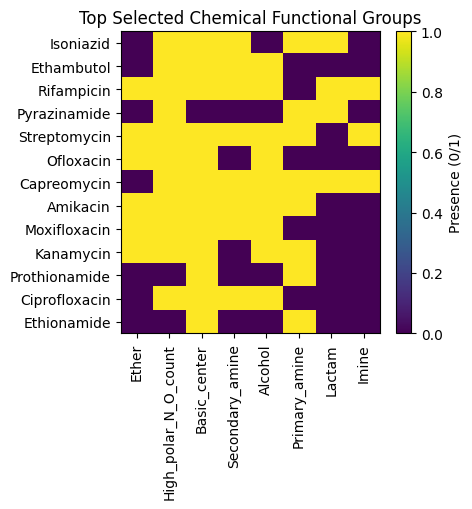

In [38]:
import matplotlib.pyplot as plt

# 子矩阵：行=Drug，列=top features
df_plot = df_fg.set_index("Drug")[top_features]

plt.figure(figsize=(0.6 * len(top_features), 0.4 * len(df_plot)))
plt.imshow(df_plot.values, aspect="auto")

plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(df_plot.index)), df_plot.index)

plt.colorbar(label="Presence (0/1)")
plt.title("Top Selected Chemical Functional Groups")

plt.tight_layout()
plt.show()

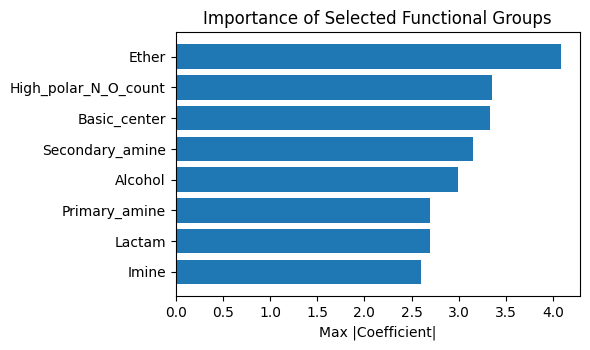

In [39]:
import numpy as np
import pandas as pd

# 每个功能团的最大绝对权重
feature_names = list(SMARTS.keys())
feature_strength = np.max(np.abs(imc.coef_H_), axis=1)

# 取 top_features 对应的权重
strength = pd.Series(
    {f: feature_strength[feature_names.index(f)] for f in top_features}
).sort_values()

plt.figure(figsize=(6, 0.45 * len(strength)))
plt.barh(strength.index, strength.values)

plt.xlabel("Max |Coefficient|")
plt.title("Importance of Selected Functional Groups")

plt.tight_layout()
plt.show()

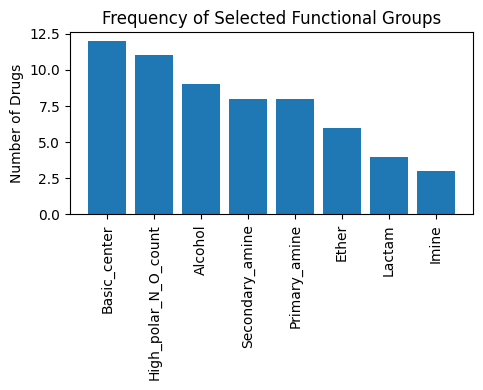

In [40]:
freq = df_plot.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(0.6 * len(freq), 4))
plt.bar(freq.index, freq.values)
plt.ylabel("Number of Drugs")
plt.xticks(rotation=90)
plt.title("Frequency of Selected Functional Groups")

plt.tight_layout()
plt.show()

In [41]:
features_to_draw = top_features  # top 6 - 8

# Others to play around
# features_to_draw = [
#     "Aromatic_ring",
#     "Heteroaromatic",
#     "Amide",
#     "Carboxylic_acid",
#     "Nitro",
#     "Basic_center",
#     "Alcohol",
#     "Aliphatic_ring",
# ]

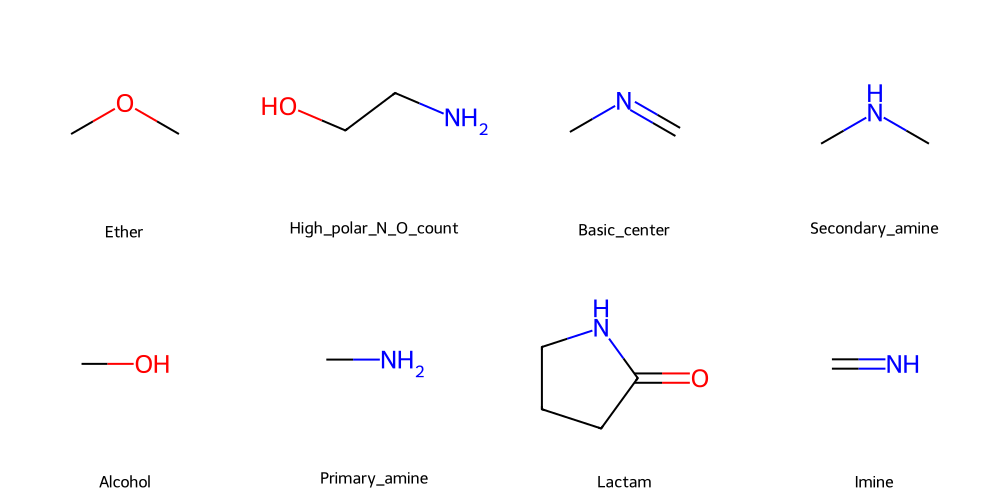

In [42]:
from rdkit import Chem
from rdkit.Chem import Draw

mols, labels = [], []

for f in top_features:  # your selected 6–8 features
    if f in FG_DISPLAY:
        mol = Chem.MolFromSmiles(FG_DISPLAY[f])
        if mol:
            mols.append(mol)
            labels.append(f)

img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 250), legends=labels)

img

#### Better display

In [43]:
FG_DISPLAY_LABELS = {
    "Basic_center": "NHx (Basic amine)",
    "Primary_amine": "NH2 (Primary amine)",
    "Secondary_amine": "NH (Secondary amine)",
    "Tertiary_amine": "N",
}

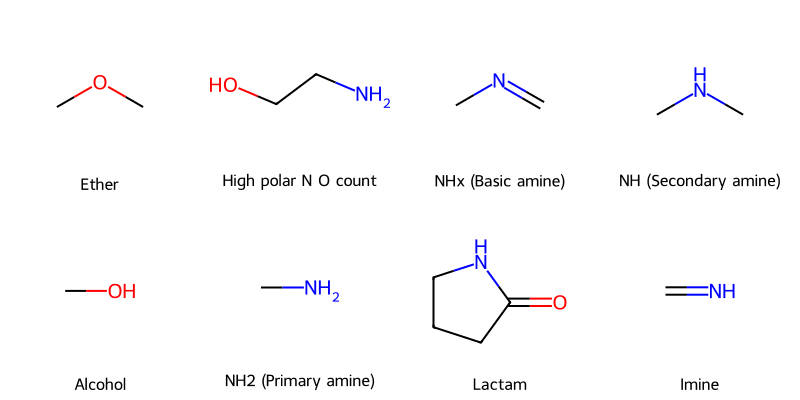

In [83]:
from rdkit import Chem
from rdkit.Chem import Draw

mols, legends = [], []

for f in features_to_draw:
    mol = Chem.MolFromSmiles(FG_DISPLAY[f])
    mols.append(mol)
    # legend: use special label if defined, else prettified name
    if f in FG_DISPLAY_LABELS:
        legends.append(FG_DISPLAY_LABELS[f])
    else:
        legends.append(f.replace("_", " "))
    labels.append(f.replace("_", " "))

img_A = Draw.MolsToGridImage(
    mols, molsPerRow=4, subImgSize=(200, 200), legends=legends, useSVG=True
)

img_A

In [84]:
from PIL.Image import Image

print(type(img_A))  # should be PIL.Image.Image

# save(img_A, path = PATH_FIGURE, filename="functional_groups_structure.png")
with open(os.path.join(PATH_FIGURE, "functional_groups_structure.svg"), "w") as f:
    f.write(img_A.data)

<class 'IPython.core.display.SVG'>


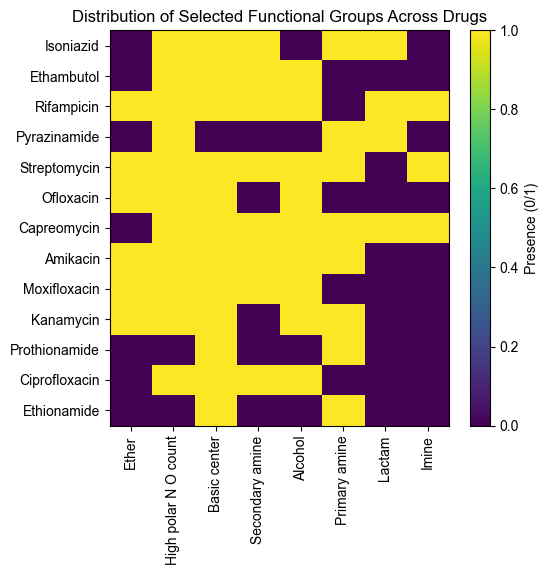

In [86]:
import matplotlib.pyplot as plt

df_plot = df_fg.set_index("Drug")[features_to_draw]

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(0.7 * len(features_to_draw), 0.45 * len(df_plot)))
plt.imshow(df_plot.values, aspect="auto")

plt.xticks(
    range(len(features_to_draw)),
    [f.replace("_", " ") for f in features_to_draw],
    rotation=90,
)
plt.yticks(range(len(df_plot.index)), df_plot.index)

plt.colorbar(label="Presence (0/1)")
plt.title("Distribution of Selected Functional Groups Across Drugs")

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIGURE, "functional_groups_heatmap.pdf"), dpi=300)
plt.show()

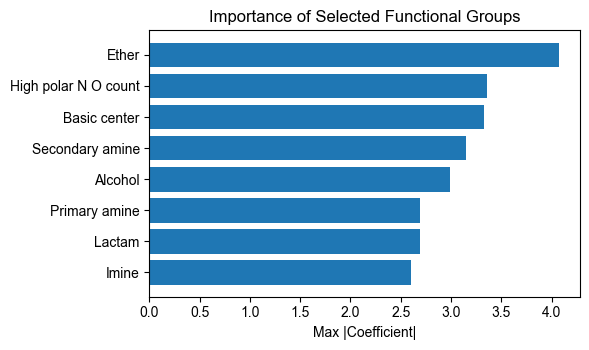

In [87]:
import numpy as np
import pandas as pd

feature_names = list(SMARTS.keys())
feature_strength = np.max(np.abs(imc.coef_H_), axis=1)

importance = pd.Series(
    {f: feature_strength[feature_names.index(f)] for f in features_to_draw}
).sort_values()

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(6, 0.45 * len(importance)))
plt.barh(importance.index.str.replace("_", " "), importance.values)

plt.xlabel("Max |Coefficient|")
plt.title("Importance of Selected Functional Groups")

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIGURE, "functional_groups_importance.pdf"), dpi=300)
plt.show()